# Ãƒâ€°valuation hors ligne : seuil, lissage et suivi (mode synthÃƒÂ©tique)

Ce notebook teste la logique de reconnaissance **sans camÃƒÂ©ra et sans modÃƒÂ¨le**.
Les embeddings sont gÃƒÂ©nÃƒÂ©rÃƒÂ©s alÃƒÂ©atoirement : aucun visage rÃƒÂ©el, aucune donnÃƒÂ©e rÃƒÂ©elle.

Il rÃƒÂ©pond ÃƒÂ  trois questions :
1. Quel seuil de similaritÃƒÂ© `SEUIL` (dans `src/boutique/config.py`) sÃƒÂ©pare le mieux les bonnes et les mauvaises reconnaissances ?
2. Combien de dÃƒÂ©tections faut-il avant qu'un client s'affiche, et combien de fausses alertes le lissage laisse passer ?
3. Le pipeline complet (suivi, reconnaissance, lissage) donne-t-il le comportement attendu, une dÃƒÂ©tection sur K ?

**Limite.** Les scores synthÃƒÂ©tiques ne ressemblent pas ÃƒÂ  ceux d'une vraie camÃƒÂ©ra. Le seuil de la dÃƒÂ©mo doit ÃƒÂªtre recalibrÃƒÂ© avec la camÃƒÂ©ra et l'ÃƒÂ©clairage de la dÃƒÂ©mo (voir le README racine, section recalibrage). Ce notebook fournit la mÃƒÂ©thode, pas la valeur finale.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

from boutique.config import FENETRE_DECISION, K_DETECTION, SEUIL, VOTES_MIN
from boutique.decision import Lisseur
from boutique.gallery import Galerie, construire_gabarit, normaliser
from boutique.pipeline import Pipeline

print(f"SEUIL = {SEUIL} | K = {K_DETECTION} | lissage : {VOTES_MIN} dÃƒÂ©cisions sur {FENETRE_DECISION}")

SEUIL = 0.35 | K = 3 | lissage : 3 dÃƒÂ©cisions sur 5


## 1. Embeddings synthÃƒÂ©tiques

Chaque personne a un vecteur de base unitaire. Une photo est ce vecteur plus un bruit, puis renormalisÃƒÂ©.
Le niveau de bruit varie d'une photo ÃƒÂ  l'autre, pour imiter une photo nette ou floue.

In [2]:
rng = np.random.default_rng(42)
DIMENSION = 512
NB_PERSONNES_ENROLEES = 4
NB_PERSONNES_INCONNUES = 20
PHOTOS_ENROLEMENT = 25
PHOTOS_TEST = 40


def personne():
    v = rng.normal(size=DIMENSION)
    return v / np.linalg.norm(v)


def photo(base):
    bruit = rng.uniform(0.4, 1.4)
    return normaliser(base + bruit * rng.normal(size=DIMENSION) / np.sqrt(DIMENSION))


# Personne qui ressemble ÃƒÂ  une personne enrÃƒÂ´lÃƒÂ©e : mÃƒÂ©lange de sa base et d'une base au hasard.
def sosie(base):
    melange = rng.uniform(0.3, 0.7)
    return normaliser(melange * base + (1 - melange) * personne())


bases = {f"C00{i + 1}": personne() for i in range(NB_PERSONNES_ENROLEES)}
inconnues = [sosie(list(bases.values())[i % NB_PERSONNES_ENROLEES]) for i in range(NB_PERSONNES_INCONNUES)]

galerie = Galerie({
    identifiant: construire_gabarit([photo(base) for _ in range(PHOTOS_ENROLEMENT)])
    for identifiant, base in bases.items()
})
print("Galerie :", galerie.identifiants())

Galerie : ['C001', 'C002', 'C003', 'C004']


## 2. Choix du seuil

Les personnes Ã‚Â« inconnues Ã‚Â» sont des **sosies** : elles ressemblent ÃƒÂ  des clients enrÃƒÂ´lÃƒÂ©s, ce qui rend le test plus dur qu'une comparaison avec des inconnus quelconques. Pour chaque photo de test, on regarde la meilleure correspondance dans la galerie :
- **scores Ã‚Â« mÃƒÂªme personne Ã‚Â»** : photo d'une personne enrÃƒÂ´lÃƒÂ©e, comparÃƒÂ©e ÃƒÂ  la galerie ;
- **scores d'imposteurs** : photo d'une personne jamais enrÃƒÂ´lÃƒÂ©e, comparÃƒÂ©e ÃƒÂ  toute la galerie.

Un seuil trop bas accepte des inconnus (faux positifs, FAR). Un seuil trop haut refuse des clients connus (faux nÃƒÂ©gatifs, FRR).

In [3]:
meme_personne, imposteurs = [], []
for identifiant, base in bases.items():
    for _ in range(PHOTOS_TEST):
        resultat = galerie.reconnaitre(photo(base), seuil=-1.0)
        meme_personne.append((resultat.identifiant == identifiant, resultat.score))
for base in inconnues:
    for _ in range(PHOTOS_TEST // 4):
        resultat = galerie.reconnaitre(photo(base), seuil=-1.0)
        imposteurs.append(resultat.score)

scores_meme_personne = np.array([s for _, s in meme_personne])
bonne_identite = np.array([ok for ok, _ in meme_personne])
scores_imposteurs = np.array(imposteurs)

print(f"{'seuil':>6} {'FAR (inconnus acceptÃƒÂ©s)':>26} {'FRR (clients refusÃƒÂ©s)':>24}")
for seuil in np.arange(0.20, 0.71, 0.05):
    far = np.mean(scores_imposteurs >= seuil)
    frr = np.mean(~(bonne_identite & (scores_meme_personne >= seuil)))
    marque = "  <- SEUIL actuel" if abs(seuil - SEUIL) < 0.025 else ""
    print(f"{seuil:6.2f} {far:26.1%} {frr:24.1%}{marque}")

 seuil FAR (inconnus acceptÃƒÂ©s) FRR (clients refusÃƒÂ©s)
  0.20                      99.0%                     0.0%
  0.25                      97.5%                     0.0%
  0.30                      91.5%                     0.0%
  0.35                      82.5%                     0.0%  <- SEUIL actuel
  0.40                      73.5%                     0.0%
  0.45                      64.0%                     0.0%
  0.50                      53.5%                     0.6%
  0.55                      38.5%                     0.6%
  0.60                      31.0%                    10.0%
  0.65                      22.5%                    28.7%
  0.70                      14.0%                    40.6%


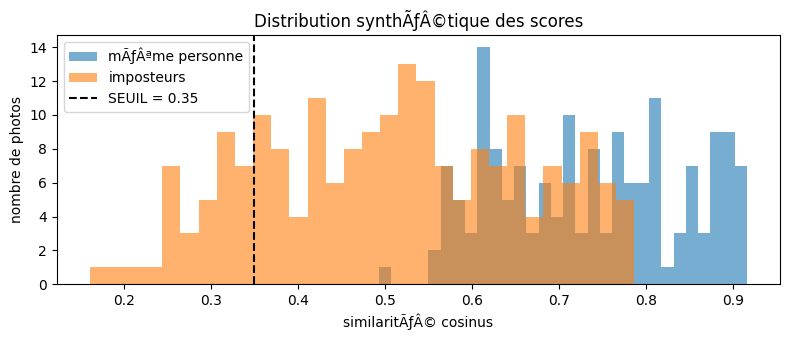

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(scores_meme_personne, bins=30, alpha=0.6, label="mÃƒÂªme personne")
ax.hist(scores_imposteurs, bins=30, alpha=0.6, label="imposteurs")
ax.axvline(SEUIL, color="black", linestyle="--", label=f"SEUIL = {SEUIL}")
ax.set_xlabel("similaritÃƒÂ© cosinus")
ax.set_ylabel("nombre de photos")
ax.legend()
ax.set_title("Distribution synthÃƒÂ©tique des scores")
plt.tight_layout()
plt.show()

Le seuil se choisit lÃƒÂ  oÃƒÂ¹ les deux courbes se sÃƒÂ©parent, en fonction du risque acceptÃƒÂ© :
en dÃƒÂ©mo, un faux positif (on affiche la mauvaise fiche) est plus gÃƒÂªnant qu'un faux nÃƒÂ©gatif (on affiche "Inconnu").

**Lecture de ce tableau.** Les sosies sont volontairement trÃƒÂ¨s proches de clients enrÃƒÂ´lÃƒÂ©s : avec cette simulation, `SEUIL = 0.35` accepte encore la plupart d'entre eux. Ce rÃƒÂ©sultat dÃƒÂ©pend du modÃƒÂ¨le de sosies choisi, il ne dit rien des vraies personnes. La valeur 0.35 vient d'usages courants pour les embeddings de type ArcFace, elle n'a pas ÃƒÂ©tÃƒÂ© mesurÃƒÂ©e sur cette camÃƒÂ©ra. Le rÃƒÂ©glage final se fait avec la vraie camÃƒÂ©ra, avec des personnes rÃƒÂ©elles de l'ÃƒÂ©quipe qui jouent les clients (voir le README racine, section recalibrage).

## 3. Lissage : vitesse d'affichage et fausses alertes

Le lissage affiche un client seulement si `VOTES_MIN` dÃƒÂ©cisions sur les `FENETRE_DECISION` derniÃƒÂ¨res concordent.
On simule une personne connue dont 80 % des dÃƒÂ©tections sont correctes, et un inconnu dont 5 % des dÃƒÂ©tections tombent sur un client.

In [5]:
def simuler_piste(identifiant_vrai, nb_detections, p_correct=0.8, p_erreur=0.05):
    lisseur = Lisseur()
    premier_affichage = None
    faux_affichages = 0
    for n in range(1, nb_detections + 1):
        tirage = rng.random()
        if identifiant_vrai is not None:
            decision = identifiant_vrai if tirage < p_correct else None
        else:
            decision = "C001" if tirage < p_erreur else None
        affiche = lisseur.ajouter(1, decision)
        if affiche is not None and identifiant_vrai is None:
            faux_affichages += 1
        if affiche == identifiant_vrai and premier_affichage is None and identifiant_vrai is not None:
            premier_affichage = n
    return premier_affichage, faux_affichages


delais = [simuler_piste("C002", 30)[0] for _ in range(2000)]
delais = [d for d in delais if d is not None]
faux = [simuler_piste(None, 30)[1] > 0 for _ in range(2000)]

print(f"Client connu : affichÃƒÂ© aprÃƒÂ¨s {np.median(delais):.0f} dÃƒÂ©tections (mÃƒÂ©diane), "
      f"{np.percentile(delais, 90):.0f} au pire dans 90 % des cas.")
print(f"Inconnu : fausse alerte sur {np.mean(faux):.1%} des pistes de 30 dÃƒÂ©tections.")

Client connu : affichÃƒÂ© aprÃƒÂ¨s 3 dÃƒÂ©tections (mÃƒÂ©diane), 5 au pire dans 90 % des cas.
Inconnu : fausse alerte sur 1.6% des pistes de 30 dÃƒÂ©tections.


Le lissage retarde un peu l'affichage, de quelques dÃƒÂ©tections, en ÃƒÂ©change de peu de fausses alertes.
Avec K = 3, une dÃƒÂ©tection a lieu toutes les 3 images. Si la camÃƒÂ©ra tourne ÃƒÂ  30 images par seconde, trois dÃƒÂ©tections prennent donc environ un quart de seconde.

## 4. Pipeline complet : suivi, reconnaissance, lissage

Un faux dÃƒÂ©tecteur renvoie toujours le mÃƒÂªme visage, celui de C001, pendant 30 images.
On vÃƒÂ©rifie qu'il n'y a qu'une dÃƒÂ©tection sur K, que l'identitÃƒÂ© s'affiche aprÃƒÂ¨s le nombre de votes requis, et qu'aucune image n'est conservÃƒÂ©e.

In [6]:
class DetecteurFictif:
    def __init__(self, embedding):
        self.embedding = embedding
        self.appels = 0

    def analyser(self, _image):
        from boutique.backend import Visage
        self.appels += 1
        return [Visage(bbox=(100.0, 80.0, 300.0, 320.0), score=0.9, embedding=self.embedding)]


detecteur = DetecteurFictif(photo(bases["C001"]))
pipeline = Pipeline(detecteur, galerie, k=K_DETECTION)

affichages_par_image = []
for image in range(30):
    affichages = pipeline.traiter(None)  # aucune image n'est jamais conservÃƒÂ©e
    affichages_par_image.append(affichages[0].identifiant if affichages else None)

premiere = next(i for i, a in enumerate(affichages_par_image) if a is not None)
print(f"DÃƒÂ©tections effectuÃƒÂ©es : {detecteur.appels} sur 30 images (une sur K = {K_DETECTION})")
print(f"Premier affichage de C001 : image {premiere}")
print("IdentitÃƒÂ©s affichÃƒÂ©es (images 0 ÃƒÂ  9) :", affichages_par_image[:10])

DÃƒÂ©tections effectuÃƒÂ©es : 10 sur 30 images (une sur K = 3)
Premier affichage de C001 : image 6
IdentitÃƒÂ©s affichÃƒÂ©es (images 0 ÃƒÂ  9) : [None, None, None, None, None, None, 'C001', 'C001', 'C001', 'C001']


## Ce que le notebook ne prouve pas

- La qualitÃƒÂ© rÃƒÂ©elle de reconnaissance (lumiÃƒÂ¨re, angle, distance de la dÃƒÂ©mo). Seule la camÃƒÂ©ra le dit.
- Les performances de InsightFace. Elles se mesurent avec `python -m boutique.bench` une fois les poids tÃƒÂ©lÃƒÂ©chargÃƒÂ©s.
- Le temps de calcul. Voir `docs/BENCH.md`.